This file is for evaluating the performance of methods on large tabular datasets.

In [3]:
import openml, os 

root_dir = os.path.dirname(os.path.dirname(os.path.dirname(os.path.dirname(os.getcwd()))))
if 'tabflex' not in os.listdir(root_dir):
    # raise ValueError('TabFlex not found')
    root_dir = os.getcwd()
openml.config.set_root_cache_directory(f'{root_dir}/tabflex/train_tabflex/datasets')

import matplotlib as mpl

In [5]:
import torch

# Check CUDA availability
if torch.cuda.is_available():
    print("CUDA is available.")
    print(f"Current CUDA device: {torch.cuda.current_device()}")
    print(f"Number of CUDA devices: {torch.cuda.device_count()}")
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available. Using CPU.")


CUDA is available.
Current CUDA device: 0
Number of CUDA devices: 1
CUDA device name: NVIDIA A100-SXM4-80GB


In [6]:
import matplotlib.pyplot as plt

from mothernet.evaluation.baselines import tabular_baselines

import seaborn as sns
import numpy as np
import warnings
warnings.simplefilter("ignore", FutureWarning)  # openml deprecation of array return type
from mothernet.datasets import load_openml_list, open_cc_valid_dids, open_cc_dids, open_cc_large_dids, new_valid_dids
from mothernet.evaluation import tabular_metrics
from mothernet.prediction.tabpfn import TabPFNClassifier
import os
from mothernet.evaluation.baselines.distill_mlp import DistilledTabPFNMLP
from mothernet.prediction.mothernet import MotherNetClassifier
from functools import partial
from mothernet.evaluation.tabular_evaluation import eval_on_datasets
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier
from mothernet.prediction.mothernet import ShiftClassifier, EnsembleMeta, MotherNetClassifier
from sklearn.impute import SimpleImputer
from mothernet.prediction.mothernet_additive import MotherNetAdditiveClassifier

from interpret.glassbox import ExplainableBoostingClassifier


from hyperfast import HyperFastClassifier

# transformers don't have max times
import warnings
import pandas as pd

import datetime

import pickle

# Datasets

In [7]:
cc_test_datasets_multiclass, cc_test_datasets_multiclass_df = load_openml_list(
    new_valid_dids,
    # [1491, 41986, 42343],
    multiclass=True,
    shuffled=True, 
    filter_for_nan=False, 
    max_samples = 1000000, 
    num_feats=5000, 
    return_capped=True,
    max_num_classes=100,
)

Number of datasets: 34


In [8]:
eval_positions = [5000000]
max_features = 5000
n_samples = 1000000
base_path = f'{root_dir}/tabflex/train_tabflex/mothernet'
overwrite = False
# max_times only affect non-nn models, nn models are not affected by max_times
# for non-nn models, when the runtime is longer than the max_time, it should stop
max_times = [1, 15, 30, 60, 60 * 5, 60 * 15, 60*60] 
metric_used = tabular_metrics.auc_metric
task_type = 'multiclass'

In [ ]:
!mkdir -p {base_path}/results
!mkdir -p {base_path}/results/tabular/
!mkdir -p {base_path}/results/tabular/multiclass/

In [9]:
cc_test_datasets_multiclass_df['isNumeric'] = (
    cc_test_datasets_multiclass_df.NumberOfSymbolicFeatures == 1
    ) & (cc_test_datasets_multiclass_df.NumberOfInstancesWithMissingValues == 0)

In [10]:
cc_test_datasets_multiclass_df['NumberOfInstances'] =  cc_test_datasets_multiclass_df['NumberOfInstances'].astype(int)
cc_test_datasets_multiclass_df['NumberOfFeatures'] =  cc_test_datasets_multiclass_df['NumberOfFeatures'].astype(int)
cc_test_datasets_multiclass_df['NumberOfClasses'] =  cc_test_datasets_multiclass_df['NumberOfClasses'].astype(int)

print(cc_test_datasets_multiclass_df[['did', 'name', 'NumberOfFeatures', 'NumberOfInstances', 'NumberOfClasses']].rename(columns={'NumberOfFeatures': "d", "NumberOfInstances":"n", "NumberOfClasses": "k"}).to_latex(index=False))

\begin{tabular}{rlrrr}
\toprule
did & name & d & n & k \\
\midrule
279 & meta_stream_intervals.arff & 75 & 45164 & 11 \\
311 & oil_spill & 50 & 937 & 2 \\
742 & fri_c4_500_100 & 101 & 500 & 2 \\
825 & boston_corrected & 21 & 506 & 2 \\
833 & bank32nh & 33 & 8192 & 2 \\
841 & stock & 10 & 950 & 2 \\
920 & fri_c2_500_50 & 51 & 500 & 2 \\
940 & water-treatment & 37 & 527 & 2 \\
981 & kdd_internet_usage & 69 & 10108 & 2 \\
1039 & hiva_agnostic & 1618 & 4229 & 2 \\
1491 & one-hundred-plants-margin & 65 & 1600 & 100 \\
1492 & one-hundred-plants-shape & 65 & 1600 & 100 \\
1503 & spoken-arabic-digit & 15 & 263256 & 10 \\
1515 & micro-mass & 1301 & 571 & 20 \\
1536 & volcanoes-b6 & 4 & 10130 & 5 \\
1541 & volcanoes-d4 & 4 & 8654 & 5 \\
1549 & autoUniv-au6-750 & 41 & 750 & 8 \\
40645 & GAMETES_Epistasis_2-Way_1000atts_0.4H_EDM-1_EDM-1_1 & 1001 & 1600 & 2 \\
40672 & fars & 30 & 100968 & 8 \\
40677 & led24 & 25 & 3200 & 10 \\
40693 & xd6 & 10 & 973 & 2 \\
40705 & tokyo1 & 45 & 959 & 2 \\
40922 & R

In [11]:
preview = cc_test_datasets_multiclass_df[['did', 'name', 'NumberOfFeatures', 'NumberOfInstances', 'NumberOfClasses']].reset_index(drop=True)
preview

,did,name,NumberOfFeatures,NumberOfInstances,NumberOfClasses
0,279,meta_stream_intervals.arff,75,45164,11
1,311,oil_spill,50,937,2
2,742,fri_c4_500_100,101,500,2
3,825,boston_corrected,21,506,2
4,833,bank32nh,33,8192,2
5,841,stock,10,950,2
6,920,fri_c2_500_50,51,500,2
7,940,water-treatment,37,527,2
8,981,kdd_internet_usage,69,10108,2
9,1039,hiva_agnostic,1618,4229,2


In [12]:
# Convert numeric columns to integers
preview['NumberOfFeatures'] = preview['NumberOfFeatures'].astype(int)
preview['NumberOfInstances'] = preview['NumberOfInstances'].astype(int)
preview['NumberOfClasses'] = preview['NumberOfClasses'].astype(int)

tex = preview.to_latex(index=False)
print(tex.replace('_', '\_'))

\begin{tabular}{rlrrr}
\toprule
did & name & NumberOfFeatures & NumberOfInstances & NumberOfClasses \\
\midrule
279 & meta\_stream\_intervals.arff & 75 & 45164 & 11 \\
311 & oil\_spill & 50 & 937 & 2 \\
742 & fri\_c4\_500\_100 & 101 & 500 & 2 \\
825 & boston\_corrected & 21 & 506 & 2 \\
833 & bank32nh & 33 & 8192 & 2 \\
841 & stock & 10 & 950 & 2 \\
920 & fri\_c2\_500\_50 & 51 & 500 & 2 \\
940 & water-treatment & 37 & 527 & 2 \\
981 & kdd\_internet\_usage & 69 & 10108 & 2 \\
1039 & hiva\_agnostic & 1618 & 4229 & 2 \\
1491 & one-hundred-plants-margin & 65 & 1600 & 100 \\
1492 & one-hundred-plants-shape & 65 & 1600 & 100 \\
1503 & spoken-arabic-digit & 15 & 263256 & 10 \\
1515 & micro-mass & 1301 & 571 & 20 \\
1536 & volcanoes-b6 & 4 & 10130 & 5 \\
1541 & volcanoes-d4 & 4 & 8654 & 5 \\
1549 & autoUniv-au6-750 & 41 & 750 & 8 \\
40645 & GAMETES\_Epistasis\_2-Way\_1000atts\_0.4H\_EDM-1\_EDM-1\_1 & 1001 & 1600 & 2 \\
40672 & fars & 30 & 100968 & 8 \\
40677 & led24 & 25 & 3200 & 10 \\
40693 &

# Method Evaluation
This section runs baselines and saves results locally.

# TabPFN

In [13]:
max_times = [10000000]
device = "cuda"
output_dir = f'{base_path}/results/tabular/multiclass'
os.makedirs(output_dir, exist_ok=True)

results_tabpfn = []

tabpfn_models = {
    'ssm_tabpfn_b4_largedatasetTrue_modellinear_attention_nsamples50000_08_01_2024_22_05_50': ('TabFast', '110'),
    'prior_diff_real_checkpoint_n_0': ('TabPFN', '100'),
    'ssm_tabpfn_b4_maxnumclasses100_modellinear_attention_numfeatures1000_n1024_validdatanew_warm_08_23_2024_19_25_40': ('TabFlex', '1410'),
    'ssm_tabpfn_modellinear_attention_08_28_2024_19_00_44': ('TabSmall', '1210'),
}

for model_string in tabpfn_models:
    model = TabPFNClassifier(
        device=device, 
        model_string=model_string, 
        epoch=tabpfn_models[model_string][1], 
        N_ensemble_configurations=3,
    )

    result = eval_on_datasets(
        'multiclass', 
        model, 
        tabpfn_models[model_string][0].lower(), 
        cc_test_datasets_multiclass, 
        eval_positions=eval_positions, 
        max_times=max_times,
        metric_used=metric_used, 
        split_numbers=[1, 2, 3, 4, 5],
        n_samples=n_samples, 
        base_path=base_path, 
        overwrite=False, 
        fetch_only=True,
        n_jobs=1, 
        device=device,
    )
    
    results_tabpfn.append(result)


# store the results as pickle
with open(f'{output_dir}/tabpfn_summary.pkl', 'wb') as f:
    pickle.dump(results_tabpfn, f)
    

evaluating tabfast on cuda


evaluating tabfast on cuda meta_stream_intervals.arff:   0%|          | 0/170 [00:00<?, ?it/s]

Loaded saved result for /opt/hpcaas/.mounts/fs-0663e2d3c38211883/home/yuchenzeng/tabflex/train_tabflex/mothernet/results/tabular/multiclass/results_tabfast_time_10000000_roc_auc_meta_stream_intervals.arff_22582_45164_1_cuda.npy


evaluating tabfast on cuda meta_stream_intervals.arff:   1%|          | 2/170 [00:00<00:31,  5.33it/s]

Loaded saved result for /opt/hpcaas/.mounts/fs-0663e2d3c38211883/home/yuchenzeng/tabflex/train_tabflex/mothernet/results/tabular/multiclass/results_tabfast_time_10000000_roc_auc_meta_stream_intervals.arff_22582_45164_2_cuda.npy
Loaded saved result for /opt/hpcaas/.mounts/fs-0663e2d3c38211883/home/yuchenzeng/tabflex/train_tabflex/mothernet/results/tabular/multiclass/results_tabfast_time_10000000_roc_auc_meta_stream_intervals.arff_22582_45164_3_cuda.npy


...

Loaded saved result for /opt/hpcaas/.mounts/fs-0663e2d3c38211883/home/yuchenzeng/tabflex/train_tabflex/mothernet/results/tabular/multiclass/results_tabsmall_time_10000000_roc_auc_porto-seguro_297606_595212_2_cuda.npy
Loaded saved result for /opt/hpcaas/.mounts/fs-0663e2d3c38211883/home/yuchenzeng/tabflex/train_tabflex/mothernet/results/tabular/multiclass/results_tabsmall_time_10000000_roc_auc_porto-seguro_297606_595212_3_cuda.npy


evaluating tabsmall on cuda porto-seguro:  96%|█████████▋| 164/170 [01:32<00:03,  1.63it/s]

Loaded saved result for /opt/hpcaas/.mounts/fs-0663e2d3c38211883/home/yuchenzeng/tabflex/train_tabflex/mothernet/results/tabular/multiclass/results_tabsmall_time_10000000_roc_auc_porto-seguro_297606_595212_4_cuda.npy
Loaded saved result for /opt/hpcaas/.mounts/fs-0663e2d3c38211883/home/yuchenzeng/tabflex/train_tabflex/mothernet/results/tabular/multiclass/results_tabsmall_time_10000000_roc_auc_porto-seguro_297606_595212_5_cuda.npy


evaluating tabsmall on cuda KDD98: 100%|██████████| 170/170 [01:32<00:00,  1.83it/s]       


Loaded saved result for /opt/hpcaas/.mounts/fs-0663e2d3c38211883/home/yuchenzeng/tabflex/train_tabflex/mothernet/results/tabular/multiclass/results_tabsmall_time_10000000_roc_auc_KDD98_41159_82318_1_cuda.npy
Loaded saved result for /opt/hpcaas/.mounts/fs-0663e2d3c38211883/home/yuchenzeng/tabflex/train_tabflex/mothernet/results/tabular/multiclass/results_tabsmall_time_10000000_roc_auc_KDD98_41159_82318_2_cuda.npy
Loaded saved result for /opt/hpcaas/.mounts/fs-0663e2d3c38211883/home/yuchenzeng/tabflex/train_tabflex/mothernet/results/tabular/multiclass/results_tabsmall_time_10000000_roc_auc_KDD98_41159_82318_3_cuda.npy
Loaded saved result for /opt/hpcaas/.mounts/fs-0663e2d3c38211883/home/yuchenzeng/tabflex/train_tabflex/mothernet/results/tabular/multiclass/results_tabsmall_time_10000000_roc_auc_KDD98_41159_82318_4_cuda.npy
Loaded saved result for /opt/hpcaas/.mounts/fs-0663e2d3c38211883/home/yuchenzeng/tabflex/train_tabflex/mothernet/results/tabular/multiclass/results_tabsmall_time_100000

# Results Preview

In [14]:
flat_results = []
for per_dataset in results_tabpfn:
    for result in per_dataset:
        row = {}
        for key in ['dataset', 'model', 'mean_metric', 'split', 'max_time']:
            row[key] = result[key]
        try:
            best_configs_key, = [k for k in result.keys() if "best_configs" in k]
        except:
            print(per_dataset)
            continue
        if result[best_configs_key][0] is not None:
            row.update(result[best_configs_key][0])
        row['mean_metric'] = float(row["mean_metric"].numpy())
        flat_results.append(row)

results_df = pd.DataFrame(flat_results)

In [15]:
results_view = results_df[['model', 'dataset', 'fit_time', 'inference_time', 'mean_metric']].copy()
# compute the mean of fit time and inference time across different splits when the model and datasets are the same
# and the rows should be reduced
results_view = results_view.groupby(['model', 'dataset']).mean().reset_index()
results_view



,model,dataset,fit_time,inference_time,mean_metric
0,tabfast,GAMETES_Epistasis_2-Way_1000atts_0.4H_EDM-1_ED...,0.001794,0.585603,0.497561
1,tabfast,GTSRB-HOG01,0.046009,4.505672,0.594260
2,tabfast,GTSRB-HOG02,0.049156,4.809677,0.594366
3,tabfast,GTSRB-HOG03,0.098807,4.756626,0.592398
4,tabfast,GTSRB-HueHist,0.029853,4.490056,0.566711
...,...,...,...,...,...
131,tabsmall,tokyo1,0.000490,0.295201,0.979122
132,tabsmall,volcanoes-b6,0.001442,0.226250,0.654798
133,tabsmall,volcanoes-d4,0.001236,0.173702,0.628320
134,tabsmall,water-treatment,0.000561,0.320343,0.983521


In [16]:
cols = ['fit_time', 'inference_time', 'mean_metric']

# Pivot the table
pivot_table = results_view.pivot(index='dataset', columns='model', values=cols)
models = pivot_table['fit_time'].columns.tolist()

# Flatten column names
pivot_table.columns = [f'{col[1]}_{col[0]}' for col in pivot_table.columns]

# Reset index to make 'dataset' a column
pivot_table = pivot_table.reset_index()

# Calculate runtime by adding fit_time and inference_time
for model in models:
    pivot_table[f'{model}_runtime'] = pivot_table[f'{model}_fit_time'] + pivot_table[f'{model}_inference_time']

# Update cols list to include runtime instead of fit_time and inference_time
cols = ['runtime', 'mean_metric']

columns_mapping = {f'{model_string}_{col}': f'{tabpfn_models[model_string][0]}_{col}' for model_string in tabpfn_models for col in cols}

# Rename columns for clarity
pivot_table = pivot_table.rename(columns=columns_mapping)

# Drop the original fit_time and inference_time columns
pivot_table = pivot_table.drop(columns=[col for col in pivot_table.columns if 'fit_time' in col or 'inference_time' in col])

pivot_table

,dataset,tabfast_mean_metric,tabflex_mean_metric,tabpfn_mean_metric,tabsmall_mean_metric,tabfast_runtime,tabflex_runtime,tabpfn_runtime,tabsmall_runtime
0,GAMETES_Epistasis_2-Way_1000atts_0.4H_EDM-1_ED...,0.497561,0.486802,0.496130,0.504201,0.587398,5.324131,1.011606,0.668101
1,GTSRB-HOG01,0.594260,0.632020,0.596238,0.593217,4.551682,41.215841,9.112163,4.728721
2,GTSRB-HOG02,0.594366,0.668257,0.596278,0.592568,4.858833,40.142157,9.092265,4.998874
3,GTSRB-HOG03,0.592398,0.637954,0.594356,0.592315,4.855433,40.205368,9.158701,4.777450
4,GTSRB-HueHist,0.566711,0.550717,0.570983,0.560369,4.519909,9.732258,8.659742,4.410088
5,KDD98,0.500000,0.609398,0.573615,0.500000,1.221103,24.091287,18.375151,1.226209
6,Kuzushiji-49,0.579050,0.631353,0.581501,0.574233,22.171366,114.655151,152.276287,21.659095
7,Run_or_walk_information,0.995663,0.991484,0.997627,0.993483,1.535082,2.033073,15.099889,1.599539
8,USPS,0.996520,0.992379,0.998299,0.996399,1.174920,2.792465,2.180470,1.298714
9,autoUniv-au6-750,0.496853,0.480367,0.501034,0.508984,0.281421,0.269133,0.200258,0.269916


In [17]:
preview.columns

Index(['did', 'name', 'NumberOfFeatures', 'NumberOfInstances',
       'NumberOfClasses'],
      dtype='object')

In [18]:
preview['dataset'] = preview['name']
# Merge the dataset preview with the pivot table
combined_table = pd.merge(pivot_table, preview[['dataset', 'NumberOfFeatures', 'NumberOfInstances', 'NumberOfClasses']], 
                          on='dataset', how='left')

# Reorder columns to put dataset information first
cols = ['dataset', 'NumberOfFeatures', 'NumberOfInstances', 'NumberOfClasses'] + [col for col in combined_table.columns if col not in ['dataset', 'NumberOfFeatures', 'NumberOfInstances', 'NumberOfClasses']]
combined_table = combined_table[cols]

for i, row in combined_table.iterrows():
    n, d, c = row['NumberOfInstances'], row['NumberOfFeatures'], row['NumberOfClasses']

    if c > 10: 
        continue
    elif n >= 50000 and d <= 100:
        row['tabflex_runtime'] = row['tabfast_runtime']
        row['tabflex_mean_metric'] = row['tabfast_mean_metric']
    elif d > 100 or (d/n>=0.2 and n >=50000):
        continue
    else:
        row['tabflex_runtime'] = row['tabsmall_runtime']
        row['tabflex_mean_metric'] = row['tabsmall_mean_metric']

    combined_table.iloc[i] = row


In [19]:
combined_table = combined_table.drop(columns=[col for col in combined_table.columns if 'tabfast' in col or 'tabsmall' in col])

# Reorder columns to show mean_metric first, then runtime, with tabpfn first, then tabflex
cols = ['dataset', 'NumberOfFeatures', 'NumberOfInstances', 'NumberOfClasses', 
        'tabpfn_mean_metric', 'tabflex_mean_metric', 'tabpfn_runtime', 'tabflex_runtime']
combined_table = combined_table[cols]

# Calculate the difference between tabflex and tabpfn mean metrics
combined_table['metric_diff'] = combined_table['tabflex_mean_metric'] - combined_table['tabpfn_mean_metric']

# Sort the table based on the difference
combined_table = combined_table.sort_values('metric_diff', ascending=False)

# Drop the temporary column used for sorting
combined_table = combined_table.drop(columns=['metric_diff'])

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
display(combined_table)

,dataset,NumberOfFeatures,NumberOfInstances,NumberOfClasses,tabpfn_mean_metric,tabflex_mean_metric,tabpfn_runtime,tabflex_runtime
14,fri_c2_500_50,51,500,2,0.763138,0.925543,0.223810,0.436088
21,micro-mass,1301,571,20,0.711804,0.820098,0.575331,4.796350
2,GTSRB-HOG02,1569,51839,43,0.596278,0.668257,9.092265,40.142157
6,Kuzushiji-49,785,270912,49,0.581501,0.631353,152.276287,114.655151
20,meta_stream_intervals.arff,75,45164,11,0.933270,0.982575,8.538585,3.894760
3,GTSRB-HOG03,2917,51839,43,0.594356,0.637954,9.158701,40.205368
23,one-hundred-plants-margin,65,1600,100,0.545893,0.584330,1.217813,0.543184
5,KDD98,478,82318,2,0.573615,0.609398,18.375151,24.091287
1,GTSRB-HOG01,1569,51839,43,0.596238,0.632020,9.112163,41.215841
24,one-hundred-plants-shape,65,1600,100,0.544277,0.566862,0.989735,0.614000


In [20]:
sum(combined_table['tabflex_mean_metric'] < combined_table['tabpfn_mean_metric'])/len(preview)

0.3235294117647059

In [21]:
sum(combined_table['tabflex_runtime'] < combined_table['tabpfn_runtime'])/len(preview)

0.5294117647058824

In [22]:
print(combined_table.to_latex(index=False, float_format="%.3f").replace('_', '\_'))

\begin{tabular}{lrrrrrrr}
\toprule
dataset & NumberOfFeatures & NumberOfInstances & NumberOfClasses & tabpfn\_mean\_metric & tabflex\_mean\_metric & tabpfn\_runtime & tabflex\_runtime \\
\midrule
fri\_c2\_500\_50 & 51 & 500 & 2 & 0.763 & 0.926 & 0.224 & 0.436 \\
micro-mass & 1301 & 571 & 20 & 0.712 & 0.820 & 0.575 & 4.796 \\
GTSRB-HOG02 & 1569 & 51839 & 43 & 0.596 & 0.668 & 9.092 & 40.142 \\
Kuzushiji-49 & 785 & 270912 & 49 & 0.582 & 0.631 & 152.276 & 114.655 \\
meta\_stream\_intervals.arff & 75 & 45164 & 11 & 0.933 & 0.983 & 8.539 & 3.895 \\
GTSRB-HOG03 & 2917 & 51839 & 43 & 0.594 & 0.638 & 9.159 & 40.205 \\
one-hundred-plants-margin & 65 & 1600 & 100 & 0.546 & 0.584 & 1.218 & 0.543 \\
KDD98 & 478 & 82318 & 2 & 0.574 & 0.609 & 18.375 & 24.091 \\
GTSRB-HOG01 & 1569 & 51839 & 43 & 0.596 & 0.632 & 9.112 & 41.216 \\
one-hundred-plants-shape & 65 & 1600 & 100 & 0.544 & 0.567 & 0.990 & 0.614 \\
porto-seguro & 38 & 595212 & 2 & 0.599 & 0.619 & 687.326 & 19.889 \\
hiva\_agnostic & 1618 & 4229

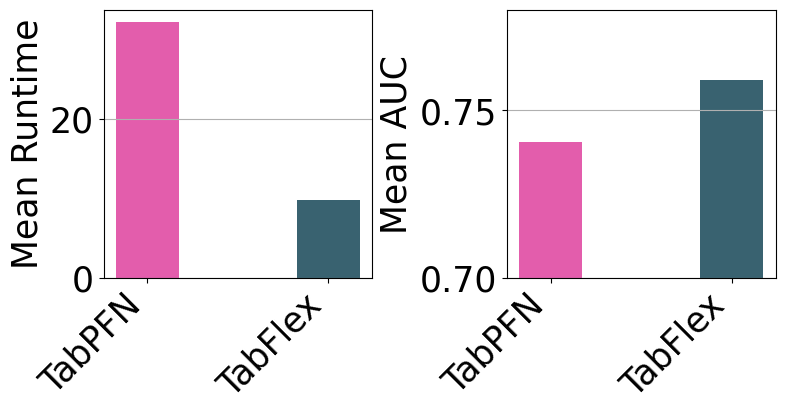

In [23]:
plt.rc('xtick', labelsize=22)
plt.rc('ytick', labelsize=22)
mpl.rcParams['patch.linewidth']=0.5 #width of the boundary of legend

# Calculate averages
metrics = ['runtime', 'mean_metric']
methods = ['tabpfn', 'tabflex']

averages = {metric: {method: combined_table[f'{method}_{metric}'].mean() for method in methods} for metric in metrics}

# Prepare for plotting
fig, axes = plt.subplots(nrows=1, ncols=2)
fig.subplots_adjust(left=0.13, bottom=.3, right=0.97, top=0.97, wspace=0.5, hspace = 0.3) #margin of the figure
fig.set_size_inches(8, 4) #exact size of the figur

width = 0.35  # Increased width to reduce space between bars
x = np.arange(len(methods))

# Define colors for TabPFN and TabFlex
colors = ['#DD3497', '#073B4C']

# Plot each metric in a separate subplot
for i, metric in enumerate(metrics):

    ax = axes[i]
    values = [averages[metric][method] for method in methods]
    bars = ax.bar(x, values, width, alpha=0.8, color=colors)

    ax.tick_params(axis='y', labelsize=25)
    ax.set_xticks(x)
    ax.set_xticklabels(['TabPFN', 'TabFlex'], rotation=45, ha='right', fontsize=25)
    ax.yaxis.grid(True)
    
    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        # ax.text(bar.get_x() + bar.get_width()/2., height,
        #         f'{height:.6f}',
        #         ha='center', va='bottom', rotation=90)

axes[1].set_ylim(0.7, .78)
axes[0].set_ylabel('Mean Runtime', fontsize=25)
axes[1].set_ylabel('Mean AUC', fontsize=25)

# Adjust layout and display the plot
plt.savefig(f'{base_path}/figures/val_set_runtime_auc.pdf')

In [24]:
!chmod 777 {base_path}/figures

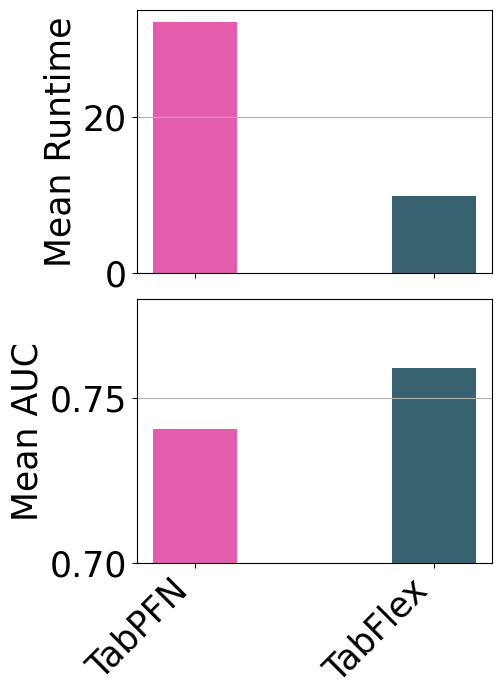

In [31]:
plt.rc('xtick', labelsize=22)
plt.rc('ytick', labelsize=22)
mpl.rcParams['patch.linewidth']=0.5 #width of the boundary of legend

# Calculate averages
metrics = ['runtime', 'mean_metric']
methods = ['tabpfn', 'tabflex']

averages = {metric: {method: combined_table[f'{method}_{metric}'].mean() for method in methods} for metric in metrics}

# Prepare for plotting
fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True)
fig.subplots_adjust(left=0.26, bottom=.18, right=0.97, top=0.97, wspace=0.5, hspace = 0.1) #margin of the figure
fig.set_size_inches(5, 7) #exact size of the figur

width = 0.35  # Increased width to reduce space between bars
x = np.arange(len(methods))

# Define colors for TabPFN and TabFlex
colors = ['#DD3497', '#073B4C']

# Plot each metric in a separate subplot
for i, metric in enumerate(metrics):

    ax = axes[i]
    values = [averages[metric][method] for method in methods]
    bars = ax.bar(x, values, width, alpha=0.8, color=colors)

    ax.tick_params(axis='y', labelsize=25)
    ax.set_xticks(x)
    ax.set_xticklabels(['TabPFN', 'TabFlex'], rotation=45, ha='right', fontsize=25)
    ax.yaxis.grid(True)
    
    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        # ax.text(bar.get_x() + bar.get_width()/2., height,
        #         f'{height:.6f}',
        #         ha='center', va='bottom', rotation=90)

axes[1].set_ylim(0.7, .78)

axes[0].set_ylabel('Mean Runtime', fontsize=25)
axes[1].set_ylabel('Mean AUC', fontsize=25)

# Adjust layout and display the plot
plt.savefig(f'{base_path}/figures/val_set_runtime_auc_horizontal.pdf')

In [ ]:
averages[metric]['tabflex']

0.7226711227613338